In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [3]:
df = pd.read_csv(r"D:\Python\archive\Middle_East_Economic_Data_1990_2024_with_Oil.csv")   

df.head()

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Dataset Shape: (455, 13)

Columns:
 Index(['Country', 'Country_Code', 'Year', 'Exports_pct_GDP',
       'FDI_net_inflows_pct_GDP', 'GDP_current_USD', 'GDP_growth_annual_pct',
       'GDP_per_capita_current_USD', 'Imports_pct_GDP',
       'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years',
       'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               455 non-null    str    
 1   Country_Code                          455 non-null    str    
 2   Year                                  455 non-null    int64  
 3   Exports_pct_GDP                       429 non-null    float64
 4   FDI_net_inflows_pct_GDP               446 non-null    float64
 5   GDP_current_USD                       448 

In [5]:
df.isnull().sum()

Country                                  0
Country_Code                             0
Year                                     0
Exports_pct_GDP                         26
FDI_net_inflows_pct_GDP                  9
GDP_current_USD                          7
GDP_growth_annual_pct                    8
GDP_per_capita_current_USD               7
Imports_pct_GDP                         26
Inflation_consumer_prices_annual_pct    60
Life_expectancy_years                   13
Unemployment_total_pct                  14
Brent_Oil_Price_USD_per_barrel           0
dtype: int64

In [6]:
df = df.fillna(0)
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

Country                                 0
Country_Code                            0
Year                                    0
Exports_pct_GDP                         0
FDI_net_inflows_pct_GDP                 0
GDP_current_USD                         0
GDP_growth_annual_pct                   0
GDP_per_capita_current_USD              0
Imports_pct_GDP                         0
Inflation_consumer_prices_annual_pct    0
Life_expectancy_years                   0
Unemployment_total_pct                  0
Brent_Oil_Price_USD_per_barrel          0
dtype: int64

In [8]:
df["trade_openness"] = df["Exports_pct_GDP"] + df["Imports_pct_GDP"]

df[["Country","Year","trade_openness"]].head()

,Country,Year,trade_openness
0,Bahrain,1990,184.828805
1,Bahrain,1991,158.867797
2,Bahrain,1992,159.291898
3,Bahrain,1993,144.763046
4,Bahrain,1994,136.473471


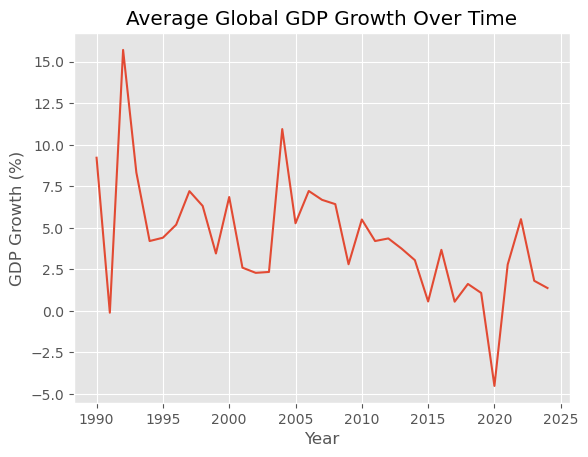

In [9]:
gdp_growth = df.groupby("Year")["GDP_growth_annual_pct"].mean()

plt.figure()
gdp_growth.plot()
plt.title("Average Global GDP Growth Over Time")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()

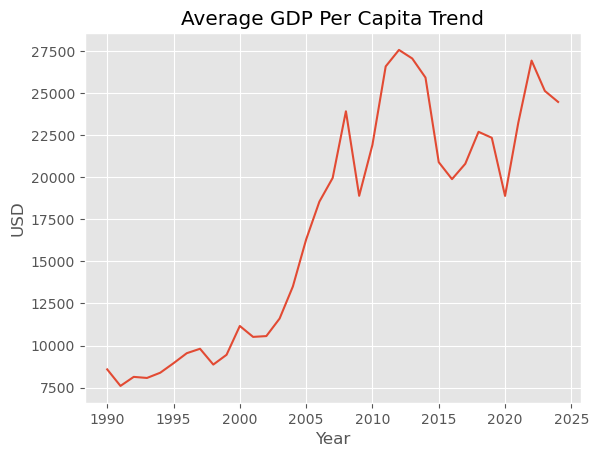

In [10]:
gdp_capita = df.groupby("Year")["GDP_per_capita_current_USD"].mean()

plt.figure()
gdp_capita.plot()
plt.title("Average GDP Per Capita Trend")
plt.xlabel("Year")
plt.ylabel("USD")
plt.show()

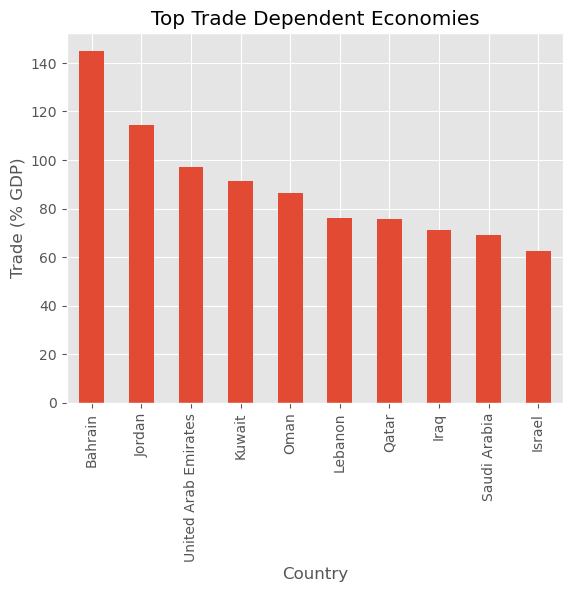

Country
Bahrain                 144.980324
Jordan                  114.245490
United Arab Emirates     97.016711
Kuwait                   91.509387
Oman                     86.561165
Lebanon                  76.238925
Qatar                    75.894401
Iraq                     71.041431
Saudi Arabia             69.159959
Israel                   62.747116
Name: trade_openness, dtype: float64

In [11]:
trade_country = df.groupby("Country")["trade_openness"].mean()

top_trade = trade_country.sort_values(ascending=False).head(10)

plt.figure()
top_trade.plot(kind="bar")
plt.title("Top Trade Dependent Economies")
plt.ylabel("Trade (% GDP)")
plt.show()

top_trade

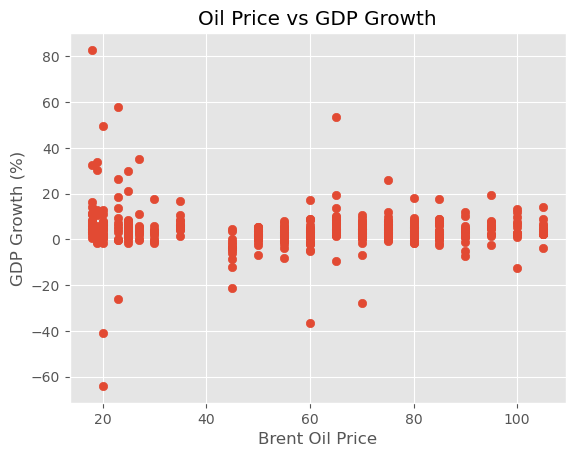

In [12]:
plt.figure()
plt.scatter(df["Brent_Oil_Price_USD_per_barrel"], df["GDP_growth_annual_pct"])

plt.xlabel("Brent Oil Price")
plt.ylabel("GDP Growth (%)")
plt.title("Oil Price vs GDP Growth")

plt.show()

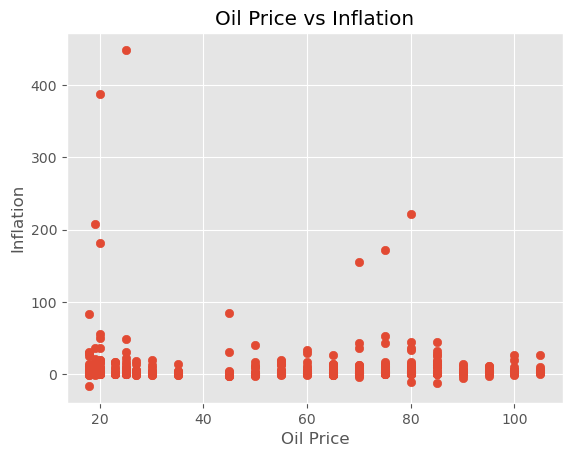

In [13]:
plt.figure()

plt.scatter(
    df["Brent_Oil_Price_USD_per_barrel"],
    df["Inflation_consumer_prices_annual_pct"]
)

plt.xlabel("Oil Price")
plt.ylabel("Inflation")
plt.title("Oil Price vs Inflation")

plt.show()

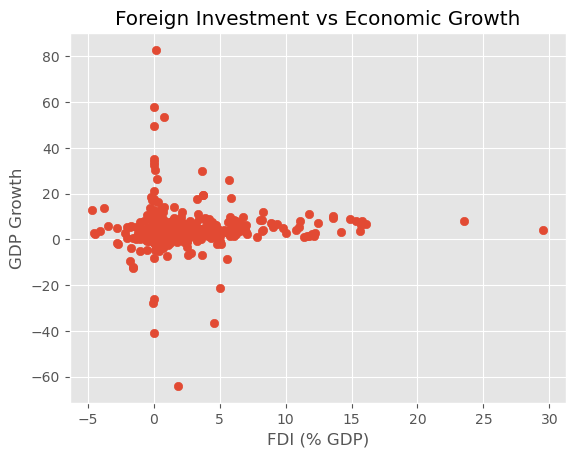

In [14]:
plt.figure()

plt.scatter(
    df["FDI_net_inflows_pct_GDP"],
    df["GDP_growth_annual_pct"]
)

plt.xlabel("FDI (% GDP)")
plt.ylabel("GDP Growth")

plt.title("Foreign Investment vs Economic Growth")

plt.show()

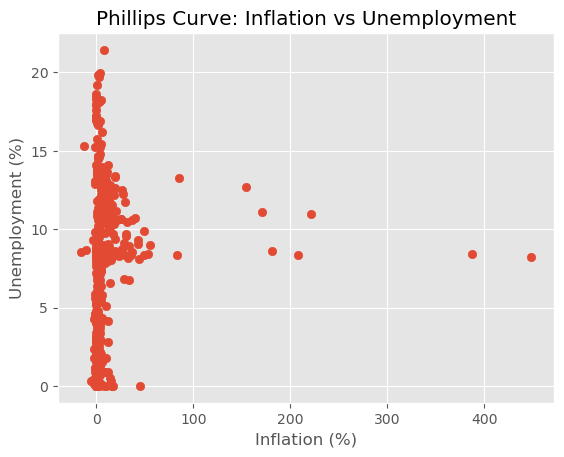

In [15]:
plt.figure()

plt.scatter(
    df["Inflation_consumer_prices_annual_pct"],
    df["Unemployment_total_pct"]
)

plt.xlabel("Inflation (%)")
plt.ylabel("Unemployment (%)")

plt.title("Phillips Curve: Inflation vs Unemployment")

plt.show()

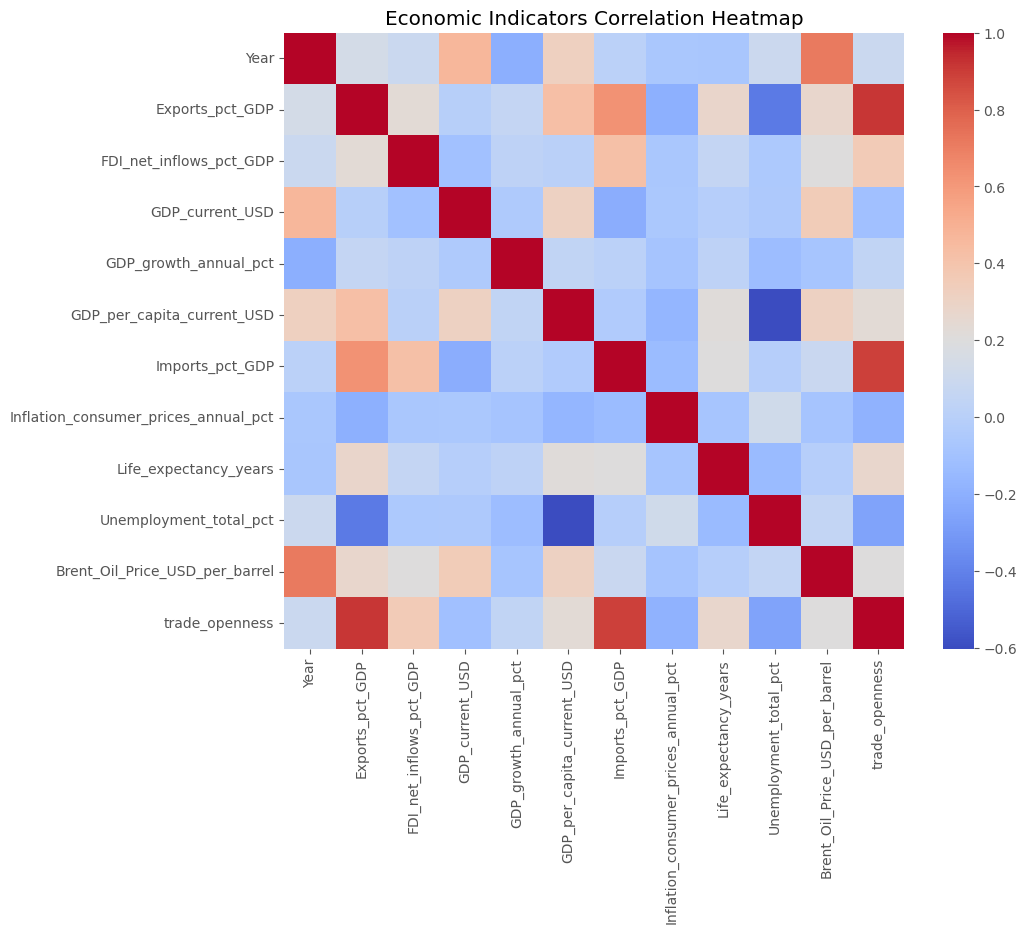

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Economic Indicators Correlation Heatmap")

plt.show()

In [17]:
features = [
    "FDI_net_inflows_pct_GDP",
    "Exports_pct_GDP",
    "Imports_pct_GDP",
    "Inflation_consumer_prices_annual_pct",
    "Unemployment_total_pct",
    "Brent_Oil_Price_USD_per_barrel",
    "GDP_per_capita_current_USD",
    "trade_openness"
]

X = df[features]

y = df["GDP_growth_annual_pct"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
print("R2 Score:", r2_score(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.018042533949660378
RMSE: 8.61613354406341


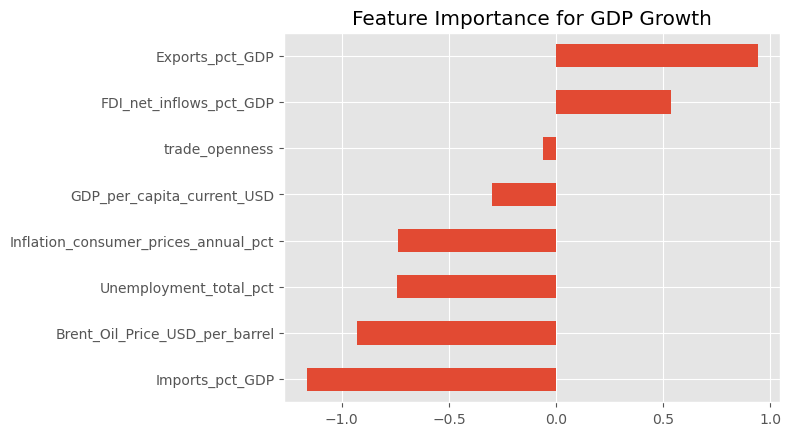

Exports_pct_GDP                         0.941031
FDI_net_inflows_pct_GDP                 0.537781
trade_openness                         -0.059663
GDP_per_capita_current_USD             -0.299622
Inflation_consumer_prices_annual_pct   -0.739074
Unemployment_total_pct                 -0.742290
Brent_Oil_Price_USD_per_barrel         -0.928769
Imports_pct_GDP                        -1.163831
dtype: float64

In [22]:
importance = pd.Series(model.coef_, index=features)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for GDP Growth")

plt.show()

importance.sort_values(ascending=False)

In [23]:
print("Total Countries:", df["Country"].nunique())

print("Year Range:", df["Year"].min(), "-", df["Year"].max())

print("\nTop Trade Dependent Countries:")
print(top_trade.head())

print("\nMost Influential Features for GDP Growth:")
print(importance.sort_values(ascending=False).head())

Total Countries: 13
Year Range: 1990 - 2024

Top Trade Dependent Countries:
Country
Bahrain                 144.980324
Jordan                  114.245490
United Arab Emirates     97.016711
Kuwait                   91.509387
Oman                     86.561165
Name: trade_openness, dtype: float64

Most Influential Features for GDP Growth:
Exports_pct_GDP                         0.941031
FDI_net_inflows_pct_GDP                 0.537781
trade_openness                         -0.059663
GDP_per_capita_current_USD             -0.299622
Inflation_consumer_prices_annual_pct   -0.739074
dtype: float64


In [24]:
df["trade_openness"] = df["Exports_pct_GDP"] + df["Imports_pct_GDP"]

df["investment_intensity"] = df["FDI_net_inflows_pct_GDP"]

In [25]:
country_df = df.groupby("Country")[[
    "GDP_growth_annual_pct",
    "GDP_per_capita_current_USD",
    "Inflation_consumer_prices_annual_pct",
    "Unemployment_total_pct",
    "trade_openness",
    "FDI_net_inflows_pct_GDP",
    "Life_expectancy_years"
]].mean()

country_df.head()

,GDP_growth_annual_pct,GDP_per_capita_current_USD,Inflation_consumer_prices_annual_pct,Unemployment_total_pct,trade_openness,FDI_net_inflows_pct_GDP,Life_expectancy_years
Country,,,,,,,
Bahrain,4.459506,19405.710037,1.277006,1.104371,144.980324,5.769484,74.665743
Egypt,4.351903,1998.249921,11.194644,9.483743,46.560764,2.576884,66.090200
Iran,3.483099,3779.252892,22.434683,10.615371,44.112716,0.541791,70.155400
Iraq,7.207452,3414.653657,44.803696,9.836857,71.041431,-0.331214,64.850486
Israel,4.281534,29697.971055,4.452943,8.162857,62.747116,3.009304,77.965645


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(country_df)

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

country_df["cluster"] = clusters

c:\Users\thear\miniconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


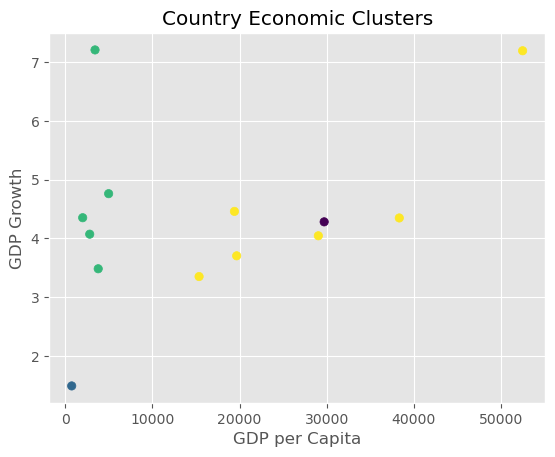

In [28]:
plt.figure()

plt.scatter(
    country_df["GDP_per_capita_current_USD"],
    country_df["GDP_growth_annual_pct"],
    c=country_df["cluster"]
)

plt.xlabel("GDP per Capita")
plt.ylabel("GDP Growth")

plt.title("Country Economic Clusters")

plt.show()

In [29]:
cluster_profile = country_df.groupby("cluster").mean()

cluster_profile

,GDP_growth_annual_pct,GDP_per_capita_current_USD,Inflation_consumer_prices_annual_pct,Unemployment_total_pct,trade_openness,FDI_net_inflows_pct_GDP,Life_expectancy_years
cluster,,,,,,,
0,4.281534,29697.971055,4.452943,8.162857,62.747116,3.009304,77.965645
1,1.489233,738.467433,11.997036,12.860800,52.903945,0.243473,62.693543
2,4.775032,3394.144047,20.458783,10.663840,70.439865,2.755250,69.086017
3,4.516480,29037.239504,1.978984,2.454786,94.186991,2.310591,74.584112


In [30]:
stability = df.groupby("Country")["GDP_growth_annual_pct"].std()

stable_countries = stability.sort_values().head(10)

stable_countries

Country
Egypt                   1.573896
Israel                  2.598666
Jordan                  2.919138
Bahrain                 3.118058
Oman                    3.155422
Saudi Arabia            3.663733
Iran                    4.142289
United Arab Emirates    4.672194
Yemen                   6.748571
Qatar                   7.971834
Name: GDP_growth_annual_pct, dtype: float64

In [31]:
growth_change = df.groupby("Country")["GDP_per_capita_current_USD"].agg(["first","last"])

growth_change["increase"] = growth_change["last"] - growth_change["first"]

growth_change.sort_values("increase", ascending=False).head(10)

,first,last,increase
Country,,,
Qatar,16721.620771,76688.694174,59967.073403
Israel,13308.311060,54176.684438,40868.373378
Saudi Arabia,11054.749505,35121.662869,24066.913364
United Arab Emirates,26709.993440,50273.506047,23563.512607
Kuwait,10937.541527,32717.718663,21780.177136
Bahrain,9342.538914,29653.568273,20311.029359
Oman,7545.703052,20285.227290,12739.524237
Jordan,1148.590055,4618.095925,3469.505870
Iran,2137.942227,5190.169590,3052.227363
